<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Pr%C3%A1ctica05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'numero_interrupciones_al_trabajador': [5,10,10,15,15,20,20,25],
    'calificacion_del_trabajador_en_la_prueba_de_hostilidad': [58,41,45,27,26,12,16,3],
})

df

,numero_interrupciones_al_trabajador,calificacion_del_trabajador_en_la_prueba_de_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


1. **Establesca una variable dependiente ($Y$) y una variable independiente ($X$)**

+ $Y$: son las interrupciones que recibe el trabajador
+ $X$: son las calificaciones del trabajador en la prueba de hostilidad

In [ ]:
# Y: calificacion_del_trabajador_en_la_prueba_de_hostilidad

# X: numero_interrupciones_al_trabajador

Y = df["calificacion_del_trabajador_en_la_prueba_de_hostilidad"]
X = df["numero_interrupciones_al_trabajador"]


2. **Realice un diagrama de dispersión para estos datos.**

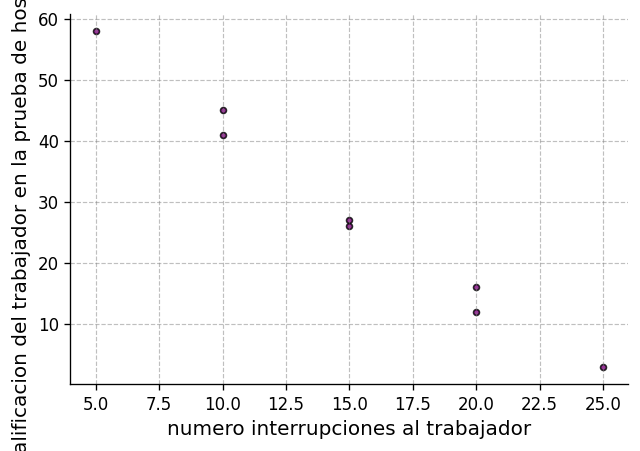

In [ ]:
import matplotlib.pyplot as plt

# Configuración del gráfico
plt.figure(figsize=(6, 4), dpi=120)

# Gráfico de dispersión con tus datos reales
plt.scatter(
    X, Y,
    marker=".",
    color='purple',
    edgecolor='black',
    alpha=0.8,
    s=50
)

# Etiquetas personalizadas para tu contexto
plt.xlabel('numero interrupciones al trabajador', fontsize=12)
plt.ylabel('calificacion del trabajador en la prueba de hostilidad', fontsize=12)

# Ajustes visuales
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.grid(visible=True, linestyle='--', linewidth=0.7, alpha=0.5, color="gray")

# Mostrar el gráfico
plt.show()

3. **¿Los datos soportan la suposición de linealidad?**

Si, porque los datos al aumentar el número de interrupciones al trabajador disminuye la calificación del trabajador en la prueba de hostilidad formando una linea diagonal que va de las esquina izquierda superior hacia la esquina inferior derecha.

4. **Calcule el coeficiente de correlación e interprete el resultado.**

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.9928
valor_p:  0.0000


El coeficiente de correlacion es $r=-0.9928$, este valor indica que la correlacion es fuerte, dado que esta muy cerca de 1. Ademas el que sea negativa, implica que aumentar la construccion de casa ($X$) aumenta las ventas de linea blanca ($Y$)

5. **Calcule el coeficiente de determinación e interprete el resultado.**


In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant (X)
modelo = sm.OLS (Y,x_constante).fit ()
y_calculada = modelo.predict (x_constante )

modelo.params

,0
const,70.5
numero_interrupciones_al_trabajador,-2.8


In [ ]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  98.58%


Con coeficiente de determinación de $$r^2=0.9858$$ indica que con las ausencias estoy justificando en un $98.58\%$ la variabilidad en el número de interrupciones del trabajador. Por lo que el modelo puede tener una buena capacidad de predicción.

6. **Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión**

In [ ]:
modelo.params

,0
const,70.5
numero_interrupciones_al_trabajador,-2.8


La ecuación de la recta es:

$$
\hat{y}=25.033529-0.352054x
$$

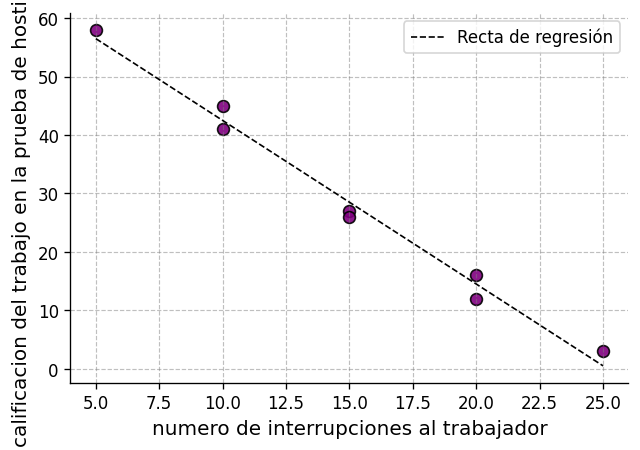

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='purple',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'numero de interrupciones al trabajador', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'calificacion del trabajo en la prueba de hostilidad', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

7. **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$



In [ ]:
modelo.conf_int(alpha=0.05)

,0,1
const,65.051384,75.948616
numero_interrupciones_al_trabajador,-3.136296,-2.463704


El verdadero $b_0$ está entre $65.051384$ y $75.948616$ con una confianza del 95%. Esto indica que una persona sin ausencias ($X=0$) tiene una categoría de salario ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $-3.136296$ y $-2.463704$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de salario.

8. **Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [ ]:
residuales = modelo.resid

/tmp/ipykernel_34997/3689749371.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


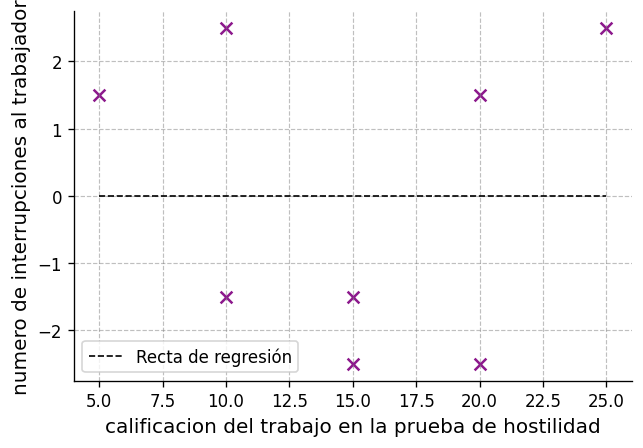

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="x",       # forma: googlear "matplotlib.markers"
    color='purple',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'calificacion del trabajo en la prueba de hostilidad', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'numero de interrupciones al trabajador', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:


+ Linealidad: Parece que sí, porque van sobre la recta, pero puede ser confuso por la cantidad de datos.
+ Normalidad: no cumple con la normalidad, porque  no hay puntos cerca de la línea.
+ Homoscedasticidad: Sí cumple con la homoscedasticidad, porque los puntos estan dispersos.
+ Independencia: Sí cumple, porque son diferentes unidades.

9. **Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.054816491127669634


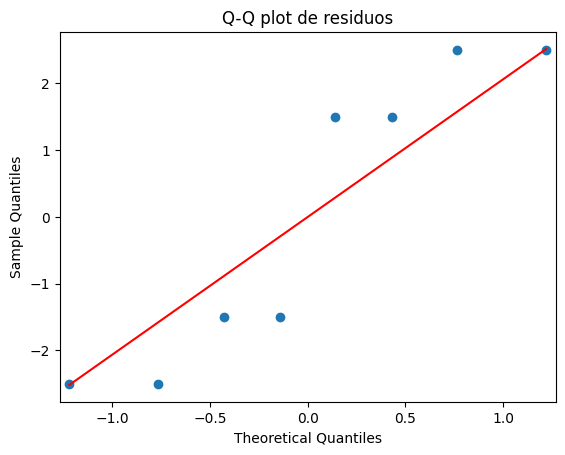

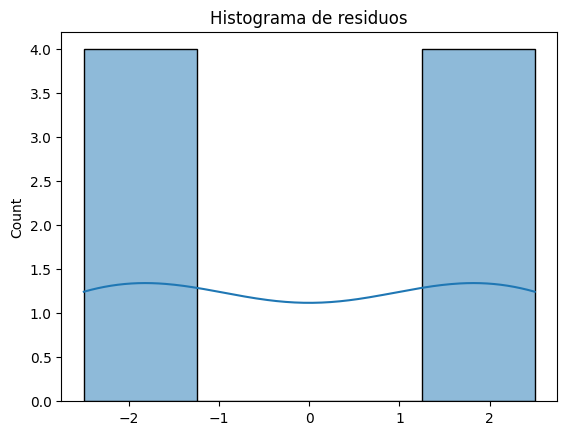

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

10. **Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2482



11. **Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

Si el modelo cumple con todos los supuestos, es confiable para interpolación.

In [ ]:

from statsmodels.formula.api import ols

# mínimo numero de interrupciones al trabajador: 5
# máximo numero de interrupciones al trabajador: 25

# interpolar, valores de x entre 5 y 25

# interpolar
y_11 = modelo.predict([1, 11])
y_22 = modelo.predict([1, 22])

print(f"Para x = 11, y =  {y_11[0]: 0.4f}")
print(f"Para x = 22, y =  {y_22[0]: 0.4f}")

Para x = 11, y =   39.7000
Para x = 22, y =   8.9000


In [ ]:
# mínimo numero de interrupciones al trabajador: 5
# máximo numero de interrupciones al trabajador: 25

# Extrapolar, valores de x que no estén entre 5 y 25

y_30 = modelo.predict([[1, 30]])

print(f"Para x = 30, y =  {y_30[0]: 0.4f}")

Para x = 30, y =  -13.5000


Con 30 interrupciones se espera que el empleado tenga una calificación negativa de -13.5000. Este valor no es confiable porque no hay calificaciones negativas.

12. **Realice una tabla ANOVA e interprete el resultado.**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

modelo_lineal = ols('calificacion_del_trabajador_en_la_prueba_de_hostilidad ~ numero_interrupciones_al_trabajador', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
numero_interrupciones_al_trabajador,1.0,2352.0,2352.000000,415.058824,9.090964e-07
Residual,6.0,34.0,5.666667,NaN,NaN


No hay correlación porque el valor-p de $9.090964e-07$ es menor a un nivel de significancia $\alpha=0.05$.

En los residuales del anova se puede ver la diferencia entre el valor real observado y el valor predicho por el modelo (la media de su respectivo grupo).